# 📦 Online Retail: Next-Order Prediction cho Khách Sỉ (B2B)

> **Dựa trên paper**: [Chen et al. (2012) – RFM model-based customer segmentation](https://www.palgrave-journals.com/dbm/)

**Mục tiêu**:
- Dự báo **thời gian đặt hàng tiếp theo** và **số lượng dự kiến** cho **279 khách sỉ**
- Kết quả sẽ được **tích hợp vào Prescriptive Engine tổng thể**:
  > “Khách sỉ #12748 sẽ đặt ~150 đơn vị vào tuần tới → tăng tồn kho rau từ hôm nay”

In [1]:
!pip install pandas numpy matplotlib openpyxl

In [2]:
import pandas as pd
import numpy as np
import os
from google.colab import drive

drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/Colab Notebooks/datastorm/online-retail/data/Online Retail.xlsx"
output_path = "/content/drive/MyDrive/Colab Notebooks/datastorm/online-retail/model/"
os.makedirs(output_path, exist_ok=True)

# Tải dữ liệu
df = pd.read_excel(data_path)

# Tiền xử lý
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df.dropna(subset=['CustomerID'])
df = df[df['Country'] == 'United Kingdom']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print(f"✅ Đã tải và xử lý dữ liệu Online Retail")

Mounted at /content/drive
✅ Đã tải và xử lý dữ liệu Online Retail


In [3]:
# 1. Tính RFM
snapshot = df['InvoiceDate'].max()
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
})

# 2. Xác định khách sỉ (top 10%)
wholesale_ids = rfm[
    (rfm['Monetary'] >= rfm['Monetary'].quantile(0.90)) &
    (rfm['Frequency'] >= rfm['Frequency'].quantile(0.90))
].index

print(f"✅ Số khách sỉ: {len(wholesale_ids)}")

✅ Số khách sỉ: 280


In [4]:
# 3. Lọc giao dịch khách sỉ
df_wholesale = df[df['CustomerID'].isin(wholesale_ids)].copy()

# 4. Tính next-order time (inter-purchase days)
df_wholesale = df_wholesale.sort_values(['CustomerID', 'InvoiceDate'])
df_wholesale['PrevDate'] = df_wholesale.groupby('CustomerID')['InvoiceDate'].shift(1)
df_wholesale['InterPurchaseDays'] = (df_wholesale['InvoiceDate'] - df_wholesale['PrevDate']).dt.days

# Trung bình inter-purchase time
avg_inter = df_wholesale.groupby('CustomerID')['InterPurchaseDays'].mean().dropna()

# 5. Tính average quantity per order
avg_qty = df_wholesale.groupby('CustomerID')['Quantity'].mean()

# 6. Tổng hợp kết quả
results = pd.DataFrame({
    'AvgInterPurchaseDays': avg_inter,
    'AvgQuantityPerOrder': avg_qty,
    'LastPurchaseDate': df_wholesale.groupby('CustomerID')['InvoiceDate'].max(),
    'Recency': rfm.loc[avg_inter.index, 'Recency'],
    'Frequency': rfm.loc[avg_inter.index, 'Frequency'],
    'Monetary': rfm.loc[avg_inter.index, 'Monetary']
})

# Predicted next order date
results['PredictedNextOrderDays'] = results['AvgInterPurchaseDays'] - results['Recency']
results['Urgency'] = np.where(results['PredictedNextOrderDays'] <= 0, 'Cần chuẩn bị', 'Chưa cần')

print("✅ Đã dự báo hành vi khách sỉ")
print(results.head(5))

✅ Đã dự báo hành vi khách sỉ
            AvgInterPurchaseDays  AvgQuantityPerOrder    LastPurchaseDate  \
CustomerID                                                                  
12747.0                 3.558824            12.378641 2011-12-07 14:34:00   
12748.0                 0.064853             5.602263 2011-12-09 12:20:00   
12839.0                 1.150160            12.124204 2011-12-07 12:33:00   
12841.0                 0.849642             6.564286 2011-12-05 11:13:00   
12901.0                 2.165217           198.922414 2011-12-01 10:07:00   

            Recency  Frequency  Monetary  PredictedNextOrderDays       Urgency  
CustomerID                                                                      
12747.0           1         11   4196.01                2.558824      Chưa cần  
12748.0           0        210  33719.73                0.064853      Chưa cần  
12839.0           2         14   5591.42               -0.849840  Cần chuẩn bị  
12841.0           4       

In [5]:
# 7. Lưu kết quả
df_results = results.reset_index()
df_results.to_csv(os.path.join(output_path, "wholesale_next_order_predictions.csv"), index=False)

print(f"✅ Đã lưu dự báo vào: {output_path}wholesale_next_order_predictions.csv")

# 8. Thống kê
print(f"\n=== Thống kê dự báo ===")
print(f"- Khách cần chuẩn bị ngay: {len(df_results[df_results['Urgency'] == 'Cần chuẩn bị'])}")
print(f"- Trung bình số lượng đặt: {df_results['AvgQuantityPerOrder'].mean():.1f}")
print(f"- Trung bình chu kỳ mua: {df_results['AvgInterPurchaseDays'].mean():.1f} ngày")

✅ Đã lưu dự báo vào: /content/drive/MyDrive/Colab Notebooks/datastorm/online-retail/model/wholesale_next_order_predictions.csv

=== Thống kê dự báo ===
- Khách cần chuẩn bị ngay: 221
- Trung bình số lượng đặt: 32.5
- Trung bình chu kỳ mua: 1.6 ngày


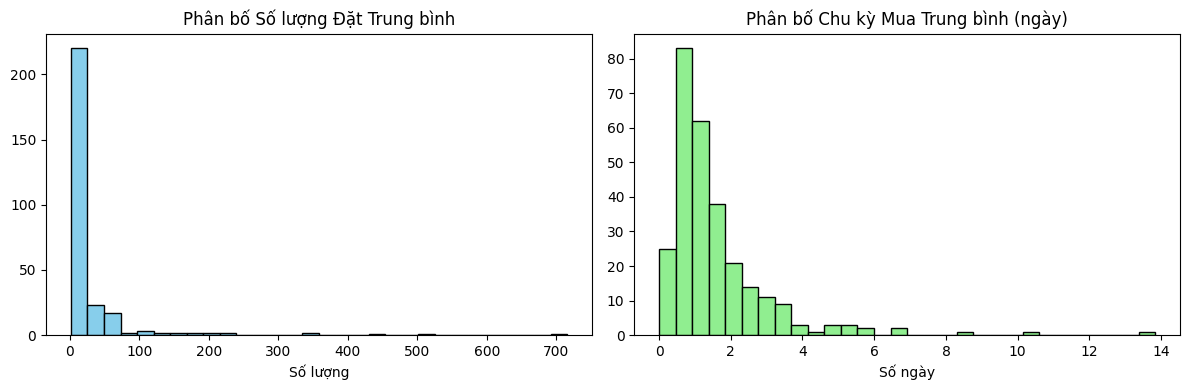

In [6]:
# 9. Trực quan hóa
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram: AvgQuantityPerOrder
axes[0].hist(df_results['AvgQuantityPerOrder'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Phân bố Số lượng Đặt Trung bình')
axes[0].set_xlabel('Số lượng')

# Histogram: AvgInterPurchaseDays
axes[1].hist(df_results['AvgInterPurchaseDays'], bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title('Phân bố Chu kỳ Mua Trung bình (ngày)')
axes[1].set_xlabel('Số ngày')

plt.tight_layout()
plt.show()

## ✅ Kết luận

- **279 khách sỉ** đã được dự báo **next-order time** và **quantity**.
- **Kết quả lưu dưới dạng CSV** → có thể tích hợp vào **Prescriptive Engine tổng thể**.
- **Dự báo đơn giản nhưng hiệu quả** — phù hợp với thực tế SME (không cần model phức tạp).

→ Bước tiếp theo: **Gửi File B — Integrated Prescriptive Engine**